# Phase 1 — Data Loading & Inventory

**Field**: Dvalin, Norwegian Sea

This notebook covers the first phase of the log conditioning workflow:
- Load the LAS file and inspect the well header
- Inventory the available curve suite
- Assess data coverage (depth range and null fraction per curve)
- Load formation tops
- Display a standard 5-track composite log over the main logging interval

In [1]:
import lasio
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.transforms import blended_transform_factory
from pathlib import Path
import importlib, sys; sys.path.insert(0, '..')
import well_config; importlib.reload(well_config)
from well_config import get_cfg, load_tops, set_plot_style, ACTIVE_WELL

# ── Well selection ────────────────────────────────────────────────────────────
WELL_NAME = ACTIVE_WELL   # ← change ACTIVE_WELL in well_config.py to switch all notebooks at once
#WELL_NAME = "65077-14S"  # ← uncomment to override for this notebook only
cfg       = get_cfg(WELL_NAME)
set_plot_style()

# ── Paths ─────────────────────────────────────────────────────────────────────
WELL_FILE = Path('..') / cfg['las_file']
TOPS_FILE = Path('..') / cfg['tops_file']

## Step 1.1 — Load LAS File

`lasio` reads LAS 2.0 files and returns a `LASFile` object. The `.df()` method returns a `pandas.DataFrame` with depth as the index.

The null value in this file is `−999.25` (CWLS standard). We replace it with `NaN` immediately so that pandas statistics and matplotlib ignore null samples automatically.

In [2]:
las = lasio.read(WELL_FILE)

# ── Well header ───────────────────────────────────────────────────────────────
def _hval(las, key):
    try: return las.well[key].value
    except: return '—'

header_items = [
    ('Well',     _hval(las, 'WELL')),
    ('Field',    _hval(las, 'FLD')),
    ('Company',  _hval(las, 'COMP')),
    ('Start (m)',_hval(las, 'STRT')),
    ('Stop (m)', _hval(las, 'STOP')),
    ('Step (m)', _hval(las, 'STEP')),
    ('Null',     _hval(las, 'NULL')),
    ('Location', _hval(las, 'LOC')),
    ('Lat',      _hval(las, 'LATI')),
    ('Long',     _hval(las, 'LONG')),
]
print('─' * 45)
print('  WELL HEADER')
print('─' * 45)
for k, v in header_items:
    print(f'  {k:<12s}: {v}')
print('─' * 45)

─────────────────────────────────────────────
  WELL HEADER
─────────────────────────────────────────────
  Well        : 6507/7-15 S
  Field       : 
  Company     : 
  Start (m)   : 0.0
  Stop (m)    : 4589.9832
  Step (m)    : 0.1524
  Null        : -999.25
  Location    : 
  Lat         : —
  Long        : —
─────────────────────────────────────────────


## Step 1.2 — Curve Inventory

In [3]:
rows = []
for curve in las.curves:
    rows.append({'Mnemonic': curve.mnemonic, 'Units': curve.unit, 'Description': curve.descr})

inventory = pd.DataFrame(rows)
print(f"Total curves loaded: {len(inventory)}\n")
print(inventory.to_string(index=False))

Total curves loaded: 16

    Mnemonic Units  Description
        DEPT     m        DEPTH
        PHIE m3/m3         PHIE
        PHIT m3/m3         PHIT
        RDEP ohm.m         RDEP
        RMED ohm.m         RMED
          AC us/ft           AC
        CALI    in         CALI
         DEN g/cm3          DEN
        DENC g/cm3         DENC
          GR  gAPI           GR
         NEU m3/m3          NEU
        VWCL     _         VWCL
  BS_CALI_ED    in   BS_CALI_ED
BS_MERGED_ED    in BS_MERGED_ED
       VCOAL     _        VCOAL
         ACS us/ft          ACS


## Step 1.3 — Data Coverage Assessment

In [4]:
df = las.df()
df.replace(-999.25, np.nan, inplace=True)
df.rename(columns=cfg.get('curve_map', {}), inplace=True)
df.index.name = 'DEPTH'

total = len(df)
cov_rows = []
for col in df.columns:
    valid   = df[col].dropna()
    n_valid = len(valid)
    z_top   = valid.index[0]  if n_valid else float('nan')
    z_bot   = valid.index[-1] if n_valid else float('nan')
    cov_rows.append({
        'Curve'    : col,
        'Top (m)'  : z_top,
        'Base (m)' : z_bot,
        'N valid'  : n_valid,
        'Coverage' : f"{100 * n_valid / total:.1f}%" if n_valid else '—',
        'Mean'     : f"{valid.mean():.3f}" if n_valid else '—',
        'Min'      : f"{valid.min():.3f}"  if n_valid else '—',
        'Max'      : f"{valid.max():.3f}"  if n_valid else '—',
    })

print(pd.DataFrame(cov_rows).to_string(index=False))

     Curve   Top (m)  Base (m)  N valid Coverage    Mean    Min     Max
      PHIE 2210.1048 4549.5972    15320    50.9%   0.050  0.000   0.279
      PHIT 2210.1048 4549.5972    15320    50.9%   0.137  0.000   0.319
        RT  500.0244 4564.9896    26543    88.1%   3.741  0.415 518.573
      RMED  500.0244 4564.9896    26543    88.1%   2.944  0.404 140.060
        DT 1336.7004 4550.0544    20798    69.1% 111.903 57.600 173.460
      CALI 2245.0044 4559.9604    15136    50.3%  11.600  7.040  13.500
      RHOB 2209.9524 4549.9020    15324    50.9%   2.472  2.133   3.177
      DRHO 2209.9524 4549.9020    15324    50.9%   0.003 -0.071   0.354
        GR  500.0244 4564.9896    26359    87.5%  92.249  3.840 220.550
      NPHI 2209.9524 4549.9020    15324    50.9%   0.258  0.034   0.530
      VWCL 2210.1048 4549.5972    15320    50.9%   0.506  0.000   0.853
BS_CALI_ED  596.0364 4566.9708    26057    86.5%  14.440  8.500  20.000
        BS  596.0364 4566.9708    26057    86.5%  14.440  8.500 

## Step 1.4 — Rock Physics Curve Availability Check

In [5]:
REQUIRED = {
    'GR'   : ('Gamma ray — lithology indicator',               True),
    'CALI' : ('Caliper — borehole QC',                         True),
    'BS'   : ('Bit size — caliper reference',                  True),
    'RHOB' : ('Bulk density — elastic input',                  True),
    'DRHO' : ('Density correction — RHOB quality',             True),
    'NPHI' : ('Neutron porosity — lithology / density infill', True),
    'DT'   : ('Compressional sonic → Vp',                     True),
    'DTS'  : ('Shear sonic → Vs  (RPM calibration)',           True),
    'RT'   : ('True resistivity — Rw / saturation / Faust',   True),
    'PEF'  : ('Photoelectric factor — mineral ID',             False),
}

print(f"{'Curve':<8}  {'Present':<12}  {'Critical':<10}  Role")
print('─' * 72)
for mnem, (role, critical) in REQUIRED.items():
    present = mnem in df.columns and df[mnem].notna().any()
    flag    = '✓' if present else '✗  ← MISSING'
    crit    = 'Critical' if critical else 'Optional'
    print(f"{mnem:<8}  {flag:<12}  {crit:<10}  {role}")

Curve     Present       Critical    Role
────────────────────────────────────────────────────────────────────────
GR        ✓             Critical    Gamma ray — lithology indicator
CALI      ✓             Critical    Caliper — borehole QC
BS        ✓             Critical    Bit size — caliper reference
RHOB      ✓             Critical    Bulk density — elastic input
DRHO      ✓             Critical    Density correction — RHOB quality
NPHI      ✓             Critical    Neutron porosity — lithology / density infill
DT        ✓             Critical    Compressional sonic → Vp
DTS       ✓             Critical    Shear sonic → Vs  (RPM calibration)
RT        ✓             Critical    True resistivity — Rw / saturation / Faust
PEF       ✗  ← MISSING  Optional    Photoelectric factor — mineral ID


## Step 1.5 — Formation Tops

Formation tops are loaded from the well tops file defined in `well_config.py`. Depths are in **measured depth (MD)** to match the LAS file depth index.

For deviated wells, the difference between MD and TVD is significant at depth. All log displays use MD.

In [6]:
# ── Load picks and filter to this well ───────────────────────────────────────
f1a_tops = load_tops(TOPS_FILE, cfg['tops_well_id'])

if not f1a_tops.empty:
    has_tvd    = 'TVD'   in f1a_tops.columns
    has_tvdss  = 'TVDSS' in f1a_tops.columns
    print(f"Formation tops for {cfg['tops_well_id']} ({len(f1a_tops)} picks):\n")
    hdr = f"  {'Formation':<35}  {'MD (m)':>8}"
    if has_tvdss: hdr += f"  {'TVDss (m)':>10}"
    if has_tvd:   hdr += f"  {'TVD (m)':>8}"
    print(hdr)
    print('  ' + '─' * (len(hdr) - 2))
    for _, row in f1a_tops.iterrows():
        line = f"  {row['PICKS']:<35}  {row['DEPTH']:>8.1f}"
        if has_tvdss: line += f"  {row['TVDSS']:>10.1f}"
        if has_tvd:   line += f"  {row['TVD']:>8.1f}"
        print(line)
else:
    print(f"No formation tops loaded for {cfg['tops_well_id']}.")
    print("Add picks to the tops file to enable formation annotations.")

# ── TOPS_MD: {formation_name: MD_depth} for log annotations ──────────────────
if not f1a_tops.empty:
    TOPS_MD       = dict(zip(f1a_tops['PICKS'], f1a_tops['DEPTH']))
    RESERVOIR_TOP = cfg.get('reservoir_fm') or f1a_tops.iloc[-1]['PICKS']
else:
    TOPS_MD       = {}
    RESERVOIR_TOP = None

Formation tops for NO 6507/7-15 S (7 picks):

  Formation                              MD (m)   TVDss (m)
  ─────────────────────────────────────────────────────────
  NAUST FM                                417.0      -399.0
  KAI FM                                 1480.7     -1462.7
  SPRINGAR FM                            2122.0     -2103.9
  LANGE FM                               3029.4     -3011.3
  SPEKK FM                               3853.7     -3832.1
  GARN FM                                4267.0     -4237.9
  Not Fm                                 4350.1     -4319.9


---

## Standard Composite Log Display

Five-track display. Tracks with two curves use **separate x-axis scales**: the primary curve's scale runs along the **top** of the track; the secondary curve's scale runs along the **bottom**. Track 4 (DT + DTS) shares a single reversed scale as both sonics are in the same units and overlapping range.

| Track | Top scale | Bottom scale | Convention |
|-------|-----------|--------------|------------|
| 1 | GR: 0–150 API | CALI / BS: 6–16 in | Sand fill gold; shale fill green |
| 2 | RT: 0.2–2000 Ω·m (log) | — | Dark red; log scale critical |
| 3 | RHOB: 1.95–2.95 g/cc | NPHI: 0.45–−0.15 v/v | Red top / blue bottom; NPHI reversed |
| 4 | DT + DTS: 300–40 μs/ft (shared, reversed) | — | Navy / crimson; fast rock → right |
| 5 | DRHO: −0.5–0.5 g/cc | — | Purple; ±0.15 threshold lines |

Formation tops are shown as dashed lines across all tracks, labelled on the left of track 1.

In [7]:
def plot_composite_log(
    df, top, base,
    well_name    = 'Well',
    bs_default   = 8.5,
    tops         = None,    # dict  {name: depth_MD}  or None
    reservoir_top= None,    # name of reservoir top — drawn in blue
    figsize      = (16, 14),
):
    """
    Standard 5-track composite well log display.

    Dual-curve tracks use separate x-axis scales:
      - Primary curve scale at TOP  of track
      - Secondary curve scale at BOTTOM of track
    Track 4 (DT / DTS) shares one reversed scale.

    Parameters
    ----------
    df            : DataFrame, DEPTH as index, nulls = NaN
    top, base     : Depth window to display (m MD)
    well_name     : Figure title string
    bs_default    : Bit size (inches) used where BS curve is absent / surface value
    tops          : dict {formation_name: depth_MD} — draws lines + labels
    reservoir_top : key from `tops` dict to highlight in a distinct colour
    figsize       : (width, height) in inches
    """
    sub   = df.loc[top:base]
    depth = sub.index.values

    def get(col):
        return sub[col].values if col in sub.columns else np.full(len(depth), np.nan)

    gr   = get('GR')
    cali = get('CALI')
    bs   = get('BS')
    rt   = get('RT')
    rhob = get('RHOB')
    nphi = get('NPHI')
    dt   = get('DT')
    dts  = get('DTS')
    drho = get('DRHO')

    bs_plot = np.where(np.isnan(bs) | (bs > 30), bs_default, bs)

    # ── Figure ───────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(
        1, 5, figsize=figsize, sharey=True,
        gridspec_kw={'width_ratios': [1.4, 1.0, 1.4, 1.4, 0.9]},
    )
    # Use subplots_adjust (not tight_layout) so bottom twin-axis labels
    # and top track titles have guaranteed space
    fig.subplots_adjust(top=0.93, bottom=0.07, left=0.07, right=0.98, wspace=0.07)

    # ── Helpers ───────────────────────────────────────────────────────────────
    def style_top_axis(ax, label, color, xlim, log=False):
        """Configure the primary (top) x-axis of a track."""
        if log:
            ax.set_xscale('log')
        ax.set_xlim(*xlim)
        ax.xaxis.set_label_position('top')
        ax.xaxis.tick_top()
        ax.set_xlabel(label, color=color, fontsize=8, labelpad=3)
        ax.tick_params(axis='x', colors=color, labelsize=7, length=4)

    def add_bottom_axis(ax, label, color, xlim, log=False):
        """Add a secondary (bottom) x-axis twin to a track."""
        ax2 = ax.twiny()
        if log:
            ax2.set_xscale('log')
        ax2.set_xlim(*xlim)
        ax2.xaxis.set_ticks_position('bottom')
        ax2.xaxis.set_label_position('bottom')
        ax2.spines['bottom'].set_visible(True)
        ax2.spines['top'].set_visible(False)
        ax2.set_xlabel(label, color=color, fontsize=8, labelpad=3)
        ax2.tick_params(axis='x', colors=color, labelsize=7,
                        length=4, top=False, bottom=True)
        return ax2

    # ─────────────────────────────────────────────────────────────────────────
    # Track 1 — Gamma Ray (top) + Caliper / BS (bottom)
    # ─────────────────────────────────────────────────────────────────────────
    ax = axes[0]
    GR_CUT = 60
    ax.plot(gr, depth, color='#4A7C40', lw=0.9)
    ax.fill_betweenx(depth, gr, GR_CUT,
                     where=(gr < GR_CUT), color='#F5C518', alpha=0.55)
    ax.fill_betweenx(depth, GR_CUT, gr,
                     where=(gr >= GR_CUT), color='#7FB069', alpha=0.20)
    style_top_axis(ax, 'GR (API)', '#4A7C40', (0, 150))

    ax_cal = add_bottom_axis(ax, 'CALI / BS (in)', '#333333', (6, 16))
    ax_cal.plot(cali,    depth, color='#1A1A1A', lw=0.8, ls='--')
    ax_cal.plot(bs_plot, depth, color='#888888', lw=0.8, ls=':')

    ax.set_ylabel('Depth (m MD)', fontsize=10)
    ax.set_title('GR  |  CALI', fontsize=9, fontweight='bold', pad=14)
    ax.grid(True, alpha=0.25, lw=0.5)
    ax.invert_yaxis()   # shared — inverts all 5 tracks

    # ─────────────────────────────────────────────────────────────────────────
    # Track 2 — Resistivity  (single scale, top)
    # ─────────────────────────────────────────────────────────────────────────
    ax = axes[1]
    ax.plot(rt, depth, color='#8B0000', lw=0.8)
    style_top_axis(ax, 'RT (Ω·m)', '#8B0000', (0.2, 2000), log=True)
    ax.set_yticklabels([])
    ax.set_title('RESISTIVITY', fontsize=9, fontweight='bold', pad=14)
    ax.grid(True, alpha=0.25, lw=0.5, which='both')

    # ─────────────────────────────────────────────────────────────────────────
    # Track 3 — Density / RHOB (top, red)  +  Neutron / NPHI (bottom, blue)
    # ─────────────────────────────────────────────────────────────────────────
    ax = axes[2]
    RHOB_MIN, RHOB_MAX = 1.95, 2.95
    NPHI_HI,  NPHI_LO  = 0.45, -0.15   # reversed: high value on left

    ax.plot(rhob, depth, color='#C0392B', lw=0.9)
    style_top_axis(ax, 'RHOB (g/cc)', '#C0392B', (RHOB_MIN, RHOB_MAX))

    ax_nphi = add_bottom_axis(ax, 'NPHI (v/v)  ←  0.45', '#2980B9', (NPHI_HI, NPHI_LO))
    ax_nphi.plot(nphi, depth, color='#2980B9', lw=0.9)

    # Gas crossover fill (NPHI mapped onto RHOB axis space)
    nphi_mapped = RHOB_MIN + (NPHI_HI - nphi) / (NPHI_HI - NPHI_LO) * (RHOB_MAX - RHOB_MIN)
    ax.fill_betweenx(depth, rhob, nphi_mapped,
                     where=(nphi_mapped < rhob), color='#85C1E9', alpha=0.35)

    ax.set_yticklabels([])
    ax.set_title('RHOB  |  NPHI', fontsize=9, fontweight='bold', pad=14)
    ax.grid(True, alpha=0.25, lw=0.5)

    # ─────────────────────────────────────────────────────────────────────────
    # Track 4 — DT + DTS  (shared reversed scale, top only)
    # ─────────────────────────────────────────────────────────────────────────
    ax = axes[3]
    ax.plot(dt,  depth, color='#1B2631', lw=0.9, label='DT')
    ax.plot(dts, depth, color='#E74C3C', lw=0.9, label='DTS', alpha=0.85)
    style_top_axis(ax, 'DT / DTS  (μs/ft)  →fast', '#333333', (300, 40))
    ax.legend(loc='lower right', fontsize=7, framealpha=0.7)
    ax.set_yticklabels([])
    ax.set_title('DT  |  DTS', fontsize=9, fontweight='bold', pad=14)
    ax.grid(True, alpha=0.25, lw=0.5)

    # ─────────────────────────────────────────────────────────────────────────
    # Track 5 — DRHO  (single scale, top)
    # ─────────────────────────────────────────────────────────────────────────
    ax = axes[4]
    THRESH = 0.15
    ax.plot(drho, depth, color='#7D3C98', lw=0.8)
    ax.fill_betweenx(depth, drho, 0,
                     where=(np.abs(drho) > THRESH),  color='#E74C3C', alpha=0.40)
    ax.fill_betweenx(depth, drho, 0,
                     where=(np.abs(drho) <= THRESH), color='#7D3C98', alpha=0.12)
    ax.axvline(0,      color='#555555', lw=0.7)
    ax.axvline( THRESH, color='#E74C3C', lw=0.8, ls='--')
    ax.axvline(-THRESH, color='#E74C3C', lw=0.8, ls='--')
    style_top_axis(ax, 'DRHO (g/cc)', '#7D3C98', (-0.5, 0.5))
    ax.text(0.97, 0.01, f'|DRHO|>{THRESH}\n= flag',
            transform=ax.transAxes, fontsize=6, ha='right', va='bottom',
            color='#E74C3C')
    ax.set_yticklabels([])
    ax.set_title('DRHO', fontsize=9, fontweight='bold', pad=14)
    ax.grid(True, alpha=0.25, lw=0.5)

    # ── Depth axis ticks ─────────────────────────────────────────────────────
    axes[0].yaxis.set_major_locator(ticker.MultipleLocator(100))
    axes[0].yaxis.set_minor_locator(ticker.MultipleLocator(50))
    axes[0].tick_params(axis='y', which='major', length=5)
    axes[0].tick_params(axis='y', which='minor', length=3)

    # ── Formation tops ────────────────────────────────────────────────────────
    if tops:
        # Blended transform: x in axes fraction, y in depth (data) coordinates
        label_trans = blended_transform_factory(axes[0].transAxes, axes[0].transData)

        for name, depth_md in tops.items():
            if not (top <= depth_md <= base):
                continue   # outside display window

            is_reservoir = (name == reservoir_top)
            line_color   = '#1A5276' if is_reservoir else '#5D4E37'
            line_lw      = 1.0      if is_reservoir else 0.8

            # Dashed line across all tracks
            for ax in axes:
                ax.axhline(depth_md, color=line_color, lw=line_lw,
                           ls=(0, (7, 4)), alpha=0.85, zorder=4)

            # Formation label — left edge of track 1, just above the line
            axes[0].text(
                0.02, depth_md - (base - top) * 0.003,
                name,
                transform = label_trans,
                fontsize  = 6.5,
                va        = 'bottom',
                ha        = 'left',
                color     = line_color,
                fontweight= 'bold' if is_reservoir else 'normal',
                bbox      = dict(facecolor='white', alpha=0.75,
                                 edgecolor='none', pad=1.2),
                zorder    = 5,
            )

    # ── Title ─────────────────────────────────────────────────────────────────
    fig.suptitle(
        f'{well_name}  —  Composite Log Display  ({top:.0f}–{base:.0f} m MD)',
        fontsize=12, fontweight='bold',
    )

    return fig, axes

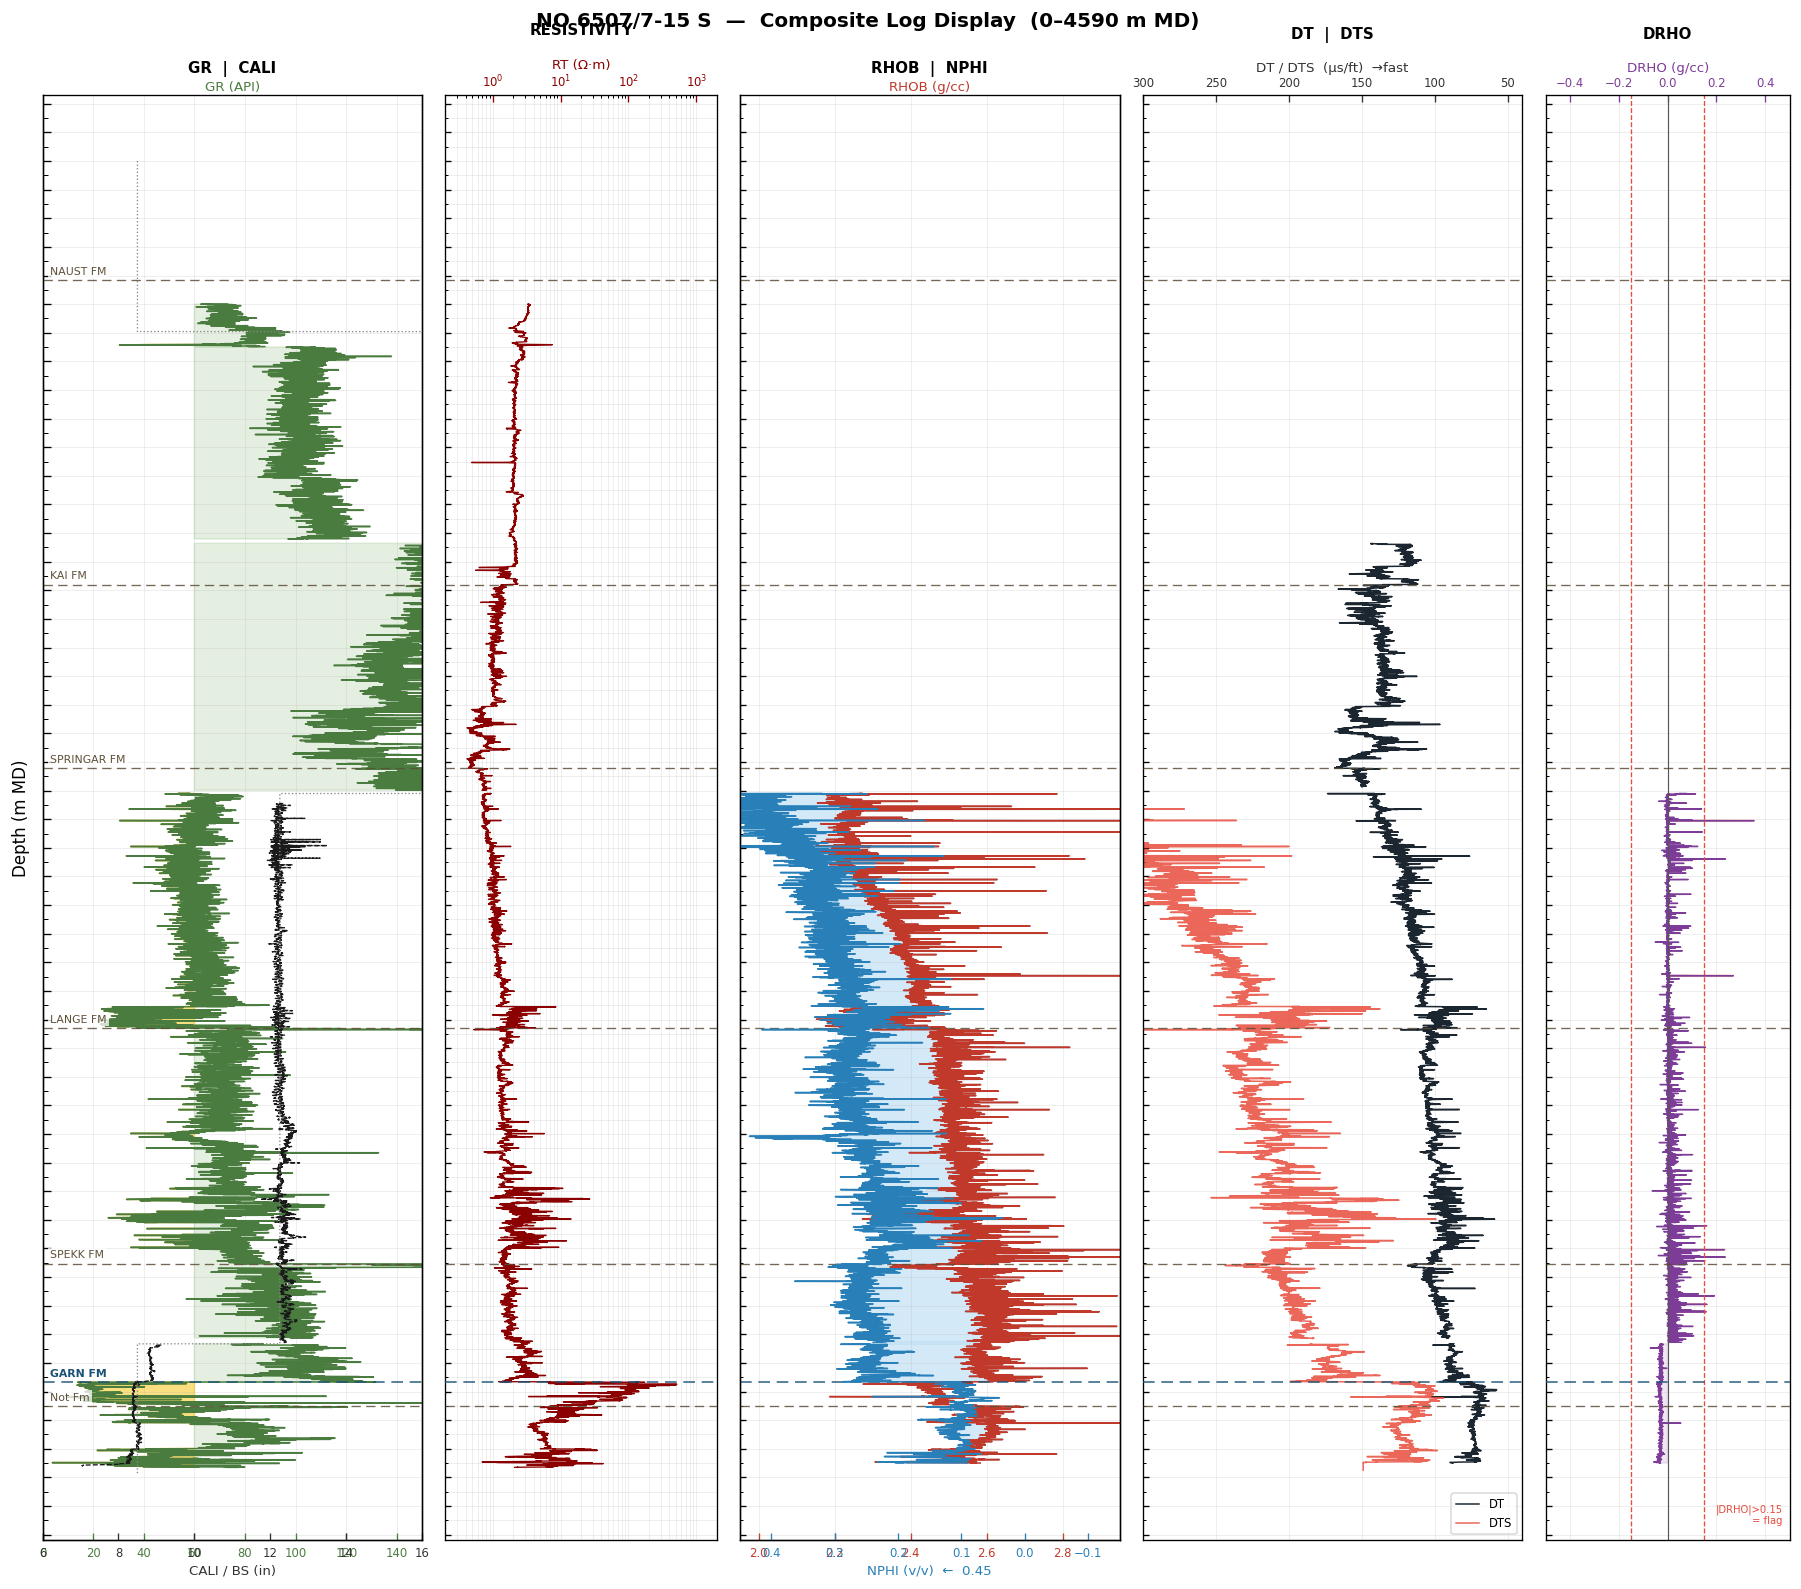

In [8]:
# ── Full logging interval ─────────────────────────────────────────────────────
LOG_TOP  = cfg['log_top']  if cfg['log_top']  is not None else df.index[0]
LOG_BASE = cfg['log_base'] if cfg['log_base'] is not None else df.index[-1]

fig, axes = plot_composite_log(
    df,
    top           = LOG_TOP,
    base          = LOG_BASE,
    well_name     = cfg['tops_well_id'],
    bs_default    = 8.5,
    tops          = TOPS_MD,
    reservoir_top = RESERVOIR_TOP,
)
plt.show()

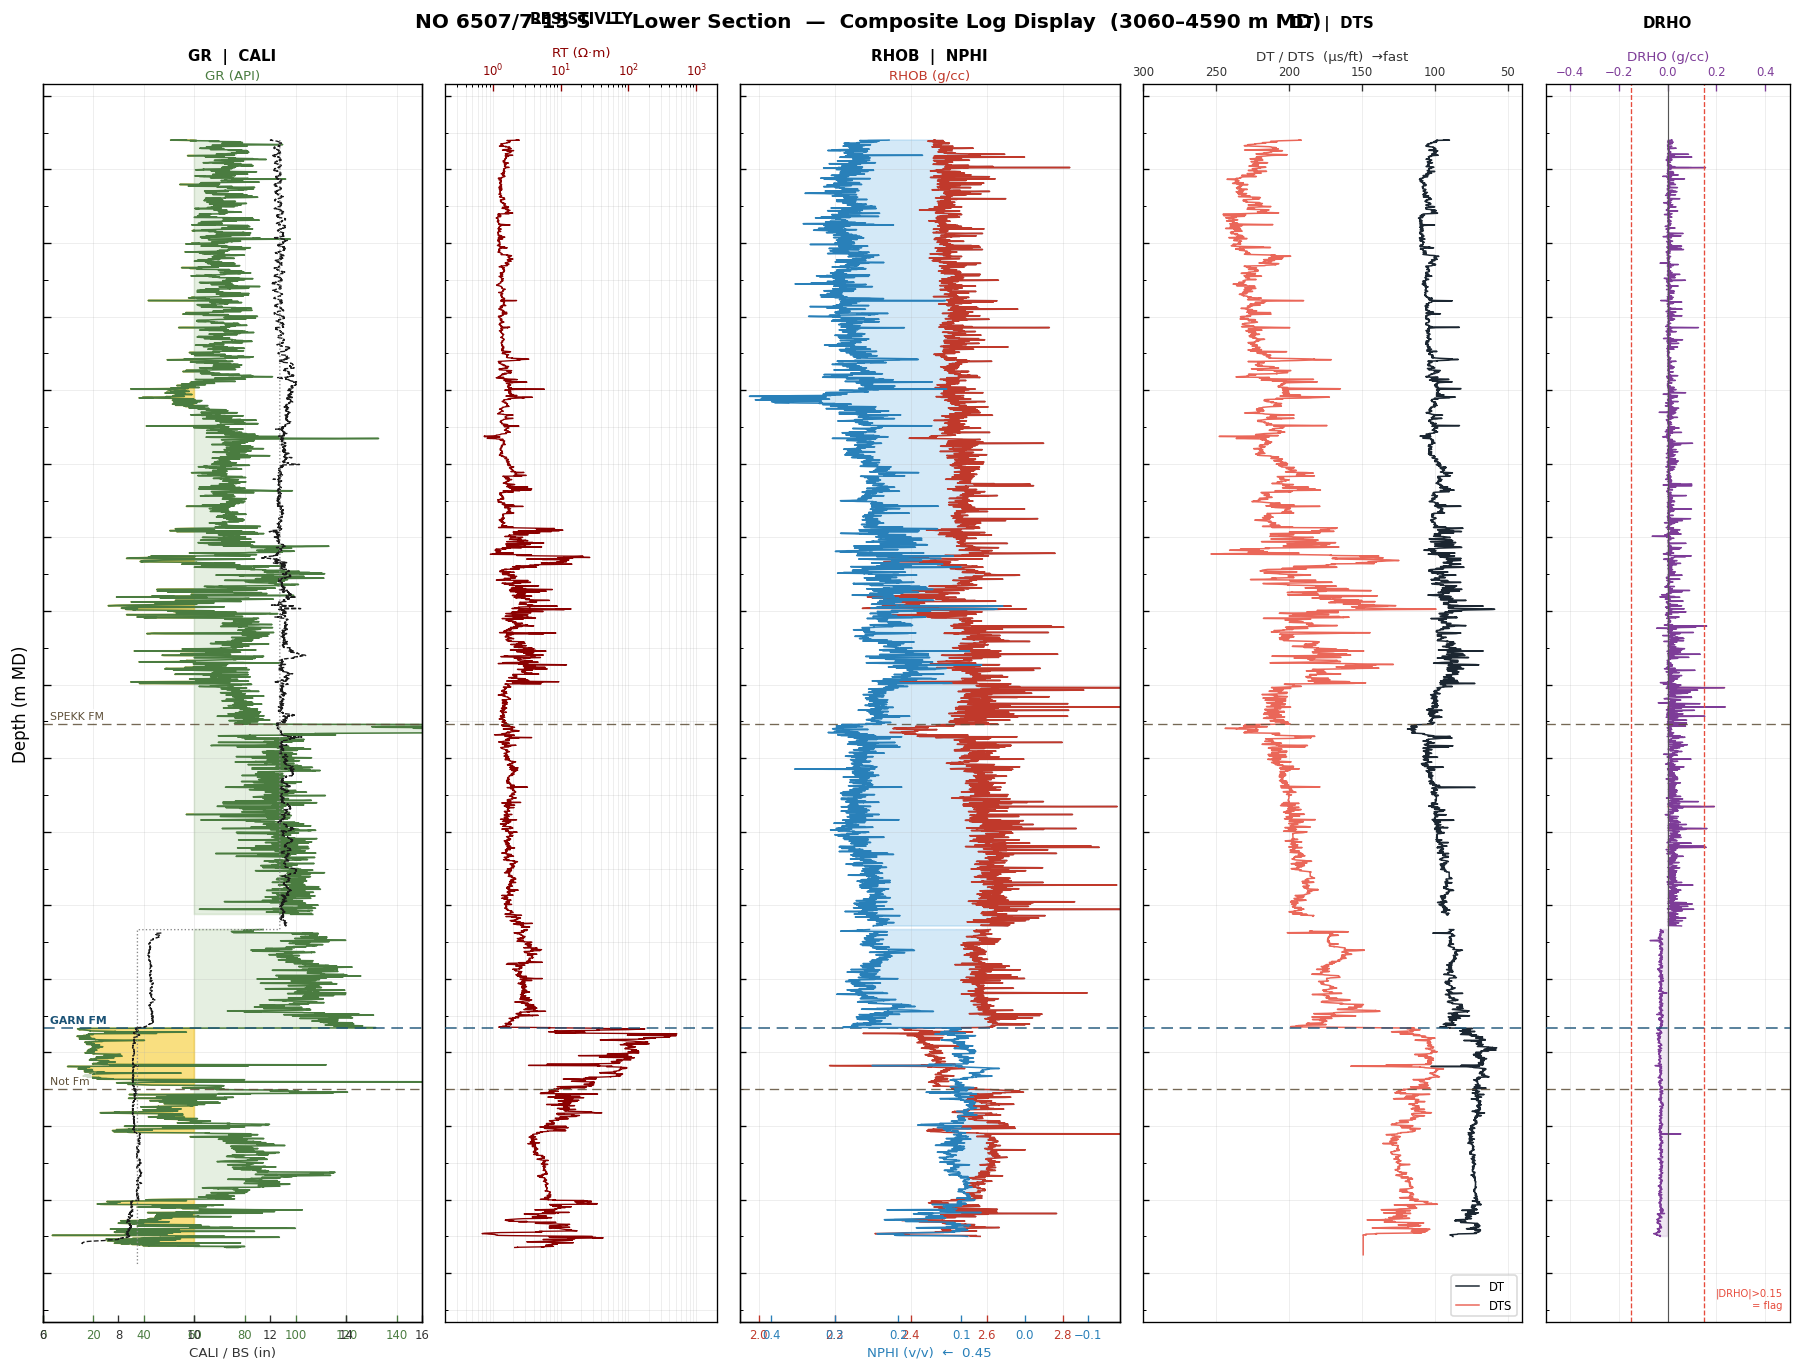

In [9]:
# ── Lower interval zoom (lower third of logged section) ──────────────────────
zoom_size = (LOG_BASE - LOG_TOP) / 3
fig, axes = plot_composite_log(
    df,
    top           = LOG_BASE - zoom_size,
    base          = LOG_BASE,
    well_name     = f"{cfg['tops_well_id']}  — Lower Section",
    bs_default    = 8.5,
    tops          = TOPS_MD,
    reservoir_top = RESERVOIR_TOP,
    figsize       = (16, 12),
)
plt.show()

## Step 1.6 — Observations from the Composite Display

**Track 1 — GR / Caliper**
- GR shows a cyclical sand-shale pattern consistent with alternating reservoir and seal facies
- Clean sand intervals (GR < 60 API, gold fill) identify potential reservoir zones — the Garn Fm sandstone is the primary target in the Dvalin area
- Caliper tracking relative to bit size indicates borehole condition; significant washouts will affect pad-tool reliability (density, neutron)
- Elevated GR in shale intervals reflects clay-rich cap rock and interbeds

**Track 2 — Resistivity**
- High RT spikes in the clean sand intervals of the Garn Fm may indicate hydrocarbon saturation in the reservoir
- Low RT in shale intervals (~1–3 Ω·m) defines the brine baseline for Rw estimation
- Tight carbonate or cemented intervals show moderate-to-elevated RT

**Track 3 — RHOB / NPHI**
- NPHI-RHOB crossover (blue shading) in clean sand intervals is diagnostic of light hydrocarbons (gas/condensate)
- Shales show the classic high-NPHI (clay-bound water), moderate-RHOB signature
- Density correction (DRHO) magnitude reflects tool contact quality

**Track 4 — DT / DTS**
- Both DT and DTS present where the shear sonic was acquired — confirms this well as a Vs calibration candidate
- DTS/DT divergence in the reservoir sands is consistent with gas effect — compressional velocity is more sensitive to gas saturation than shear velocity

**Track 5 — DRHO**
- DRHO magnitude reflects borehole rugosity; values within ±0.15 g/cc indicate reliable density measurements
- Positive DRHO excursions that correlate with caliper enlargements confirm pad lift-off

**Formation tops**
- Reservoir top (Garn Fm, blue line) should align with the onset of low GR, elevated RT, and NPHI-RHOB crossover

---
## Phase 1 Summary

| Item | Status |
|------|--------|
| LAS loaded, nulls replaced | ✓ |
| Well header documented | ✓ |
| Curve inventory complete | ✓ |
| Data coverage assessed | ✓ |
| Required rock physics curves present | ✓ All present (incl. DTS) |
| Formation tops loaded (9 picks in logging interval) | ✓ |
| Composite display with tops generated | ✓ |
| Visual QC observations noted | ✓ |

**Next**: Notebook `02_temperature_pressure.ipynb` — derive the geothermal gradient, Rw, and pressure logs (Phase 2).